# Programa de Capacitação de Processamento Digital de Sinais


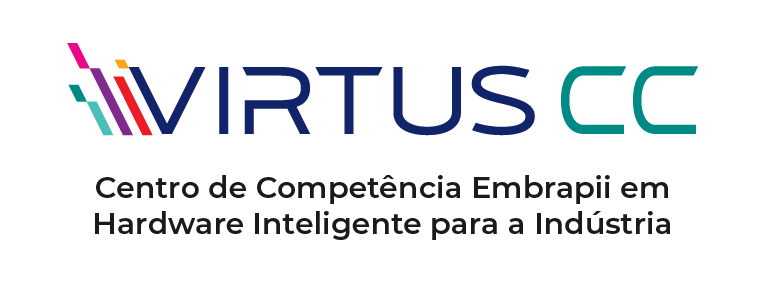


### Desenvolvido por:
-   Elmer Pimentel Farias


## Exercícios do Capítulo 3 — Processamento Digital de Sinais

Capítulo 3 do livro **Processamento Digital de Sinais** de Paulo S. R. Diniz.

## Sobre o Capítulo 3

**O Capítulo 3 apresenta os conceitos de DFT e implementações de FFT:**

- Análise de Frequência de Sinais Discretos: Por que representar sinais no domínio da frequência.

- A Transformada de Fourier Discreta (DFT): A versão computacional da análise de Fourier.

- Definição e Propriedades Principais.

A **Transformada Rápida de Fourier (FFT)** não é uma nova transformada, mas sim uma família de algoritmos extremamente eficientes para calcular a DFT.

- A ineficiência do cálculo direto da DFT: O cálculo da DFT diretamente por sua definição exige um número de operações na ordem de **$O(N^2)$**, onde $N$ é o número de amostras. Isso torna o processo inviável para sequências longas.

- O princípio da "divisão e conquista": A base dos algoritmos FFT é quebrar uma DFT de $N$ pontos em DFTs menores, de forma recursiva. Os resultados dessas DFTs menores são então combinados para produzir o resultado final.


- Algoritmos Clássicos: Os algoritmos mais comuns que implementam essa estratégia são:
    - Decimação no Tempo (DIT - *Decimation-In-Time*)
    - Decimação na Frequência (DIF - *Decimation-In-Frequency*)


- O ganho de performance: Ao utilizar a estratégia de "divisão e conquista", os algoritmos FFT reduzem drasticamente a complexidade computacional para a ordem de **$O(N \log N)$**, representando um ganho de performance massivo e tornando a análise de frequência uma ferramenta prática na computação moderna.

- Métodos Overlap-Add e Overlap-Save 

- Convolução Circular vs. Linear: Como a DFT modifica a operação de convolução e como usar isso a nosso favor.

## Objetivos Principais:
-  Implementar DFT manualmente e verificar propriedades como simetria e periodicidade.
-   Implementar o algoritmo da FFT e comparar tempo de execução e resultado com a DFT
-  Simular convolução circular via DFT e comparar com convolução linear.
- Testar ferramentas de aceleração de código, tais como Numba e CuPy.

## Vamos utilizar bibliotecas Python para representação e manipulação de sinais discretos

- NumPy : https://numpy.org/doc/stable/user/absolute_beginners.html
- Matplotlib.pyplot: https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html

# Importando as Bibliotecas


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal  

Sinal x1[n] com zero padding: 50 amostras
Sinal x2[n] cortado: 100 amostras


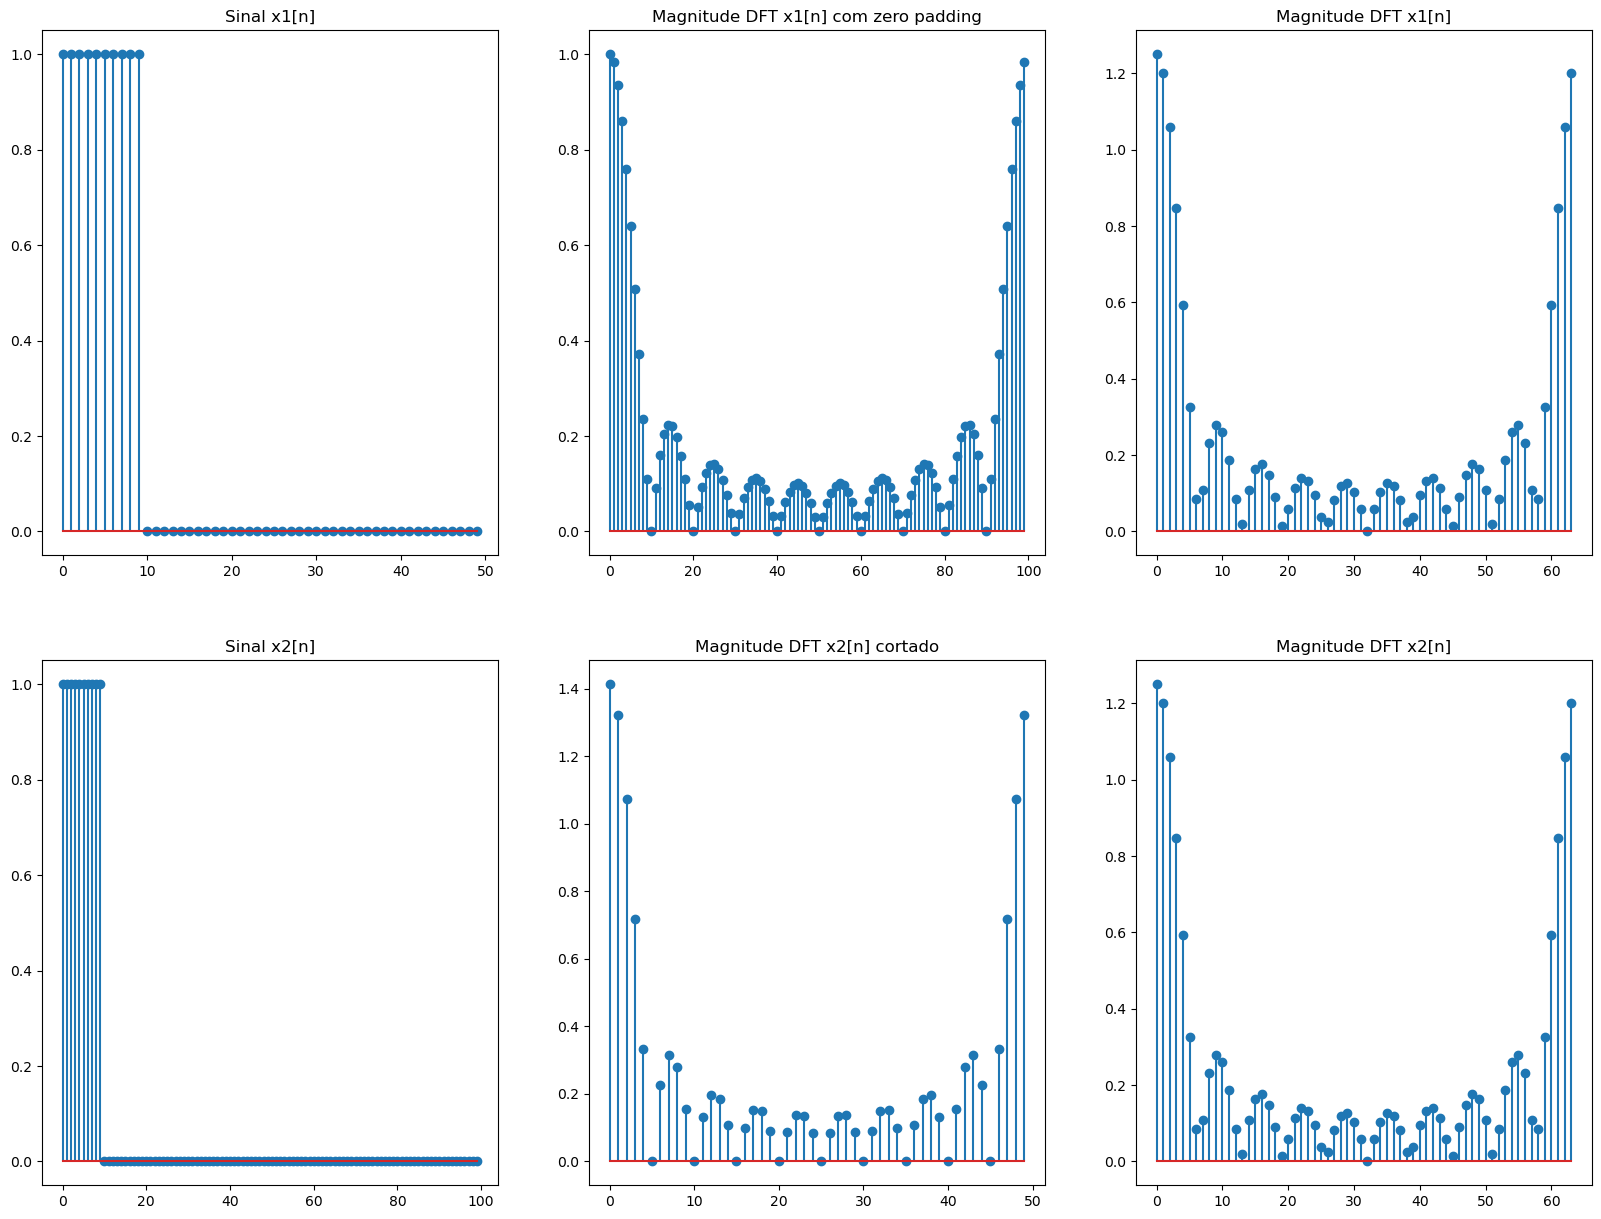

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal  

def DFT_func(signal,N):
    #Zero padding
    L=len(signal) #tamanho do sinal

    if L < N:
        signal = np.concatenate([signal,np.zeros(N-L)]) #concatena o sinal com N-L zeros
    else: #corta o sinal se for maior que N, em L>N ou L=N
        signal = signal[0:N] #corta o sinal se for maior que N
    #Transformada de Fourier Discreta

    X=np.zeros(N,dtype=complex) #inicializa o vetor da DFT com zeros
    for k in range(N):
        for n in range(N):
            X[k] += signal[n]*(np.exp((-2j*np.pi*k*n)/N)) #soma os valores da DFT

    return X/np.sqrt(N) #normaliza a DFT

L1= 50
L2= 100

n1= np.arange(L1)
n2= np.arange(L2)

x1= np.where(n1<10,1,0) #sinal retangular
x2= np.where(n2<10,1,0) #sinal retangular

N=64 #tamanho da DFT

X1_DFT= DFT_func(x1,N=L2) #DFT do sinal x1, L1=50 < N=L2=100, com zero padding
X2_DFT= DFT_func(x2,N=L1) #DFT do sinal x2, L2=100 > N=L1=50, cortado

X3_DFT= DFT_func(x1,N) #DFT do sinal x1 

X4_DFT= DFT_func(x2,N) #DFT do sinal x2 

fig , axs= plt.subplots(2,3, figsize=(20,15))

axs[0,0].stem(n1,x1)
axs[0,0].set_title('Sinal x1[n]')
axs[1,0].stem(n2,x2)
axs[1,0].set_title('Sinal x2[n]')
axs[0,1].stem(np.abs(X1_DFT))
axs[0,1].set_title('Magnitude DFT x1[n] com zero padding')
axs[1,1].stem(np.abs(X2_DFT))
axs[1,1].set_title('Magnitude DFT x2[n] cortado')
axs[0,2].stem(np.abs(X3_DFT))
axs[0,2].set_title('Magnitude DFT x1[n]')
axs[1,2].stem(np.abs(X4_DFT))
axs[1,2].set_title('Magnitude DFT x2[n]')

print('Sinal x1[n] com zero padding:', len(x1), 'amostras')
print('Sinal x2[n] cortado:', len(x2), 'amostras')

Sinal x1[n] com zero padding: 40 amostras
Sinal x2[n] cortado: 120 amostras


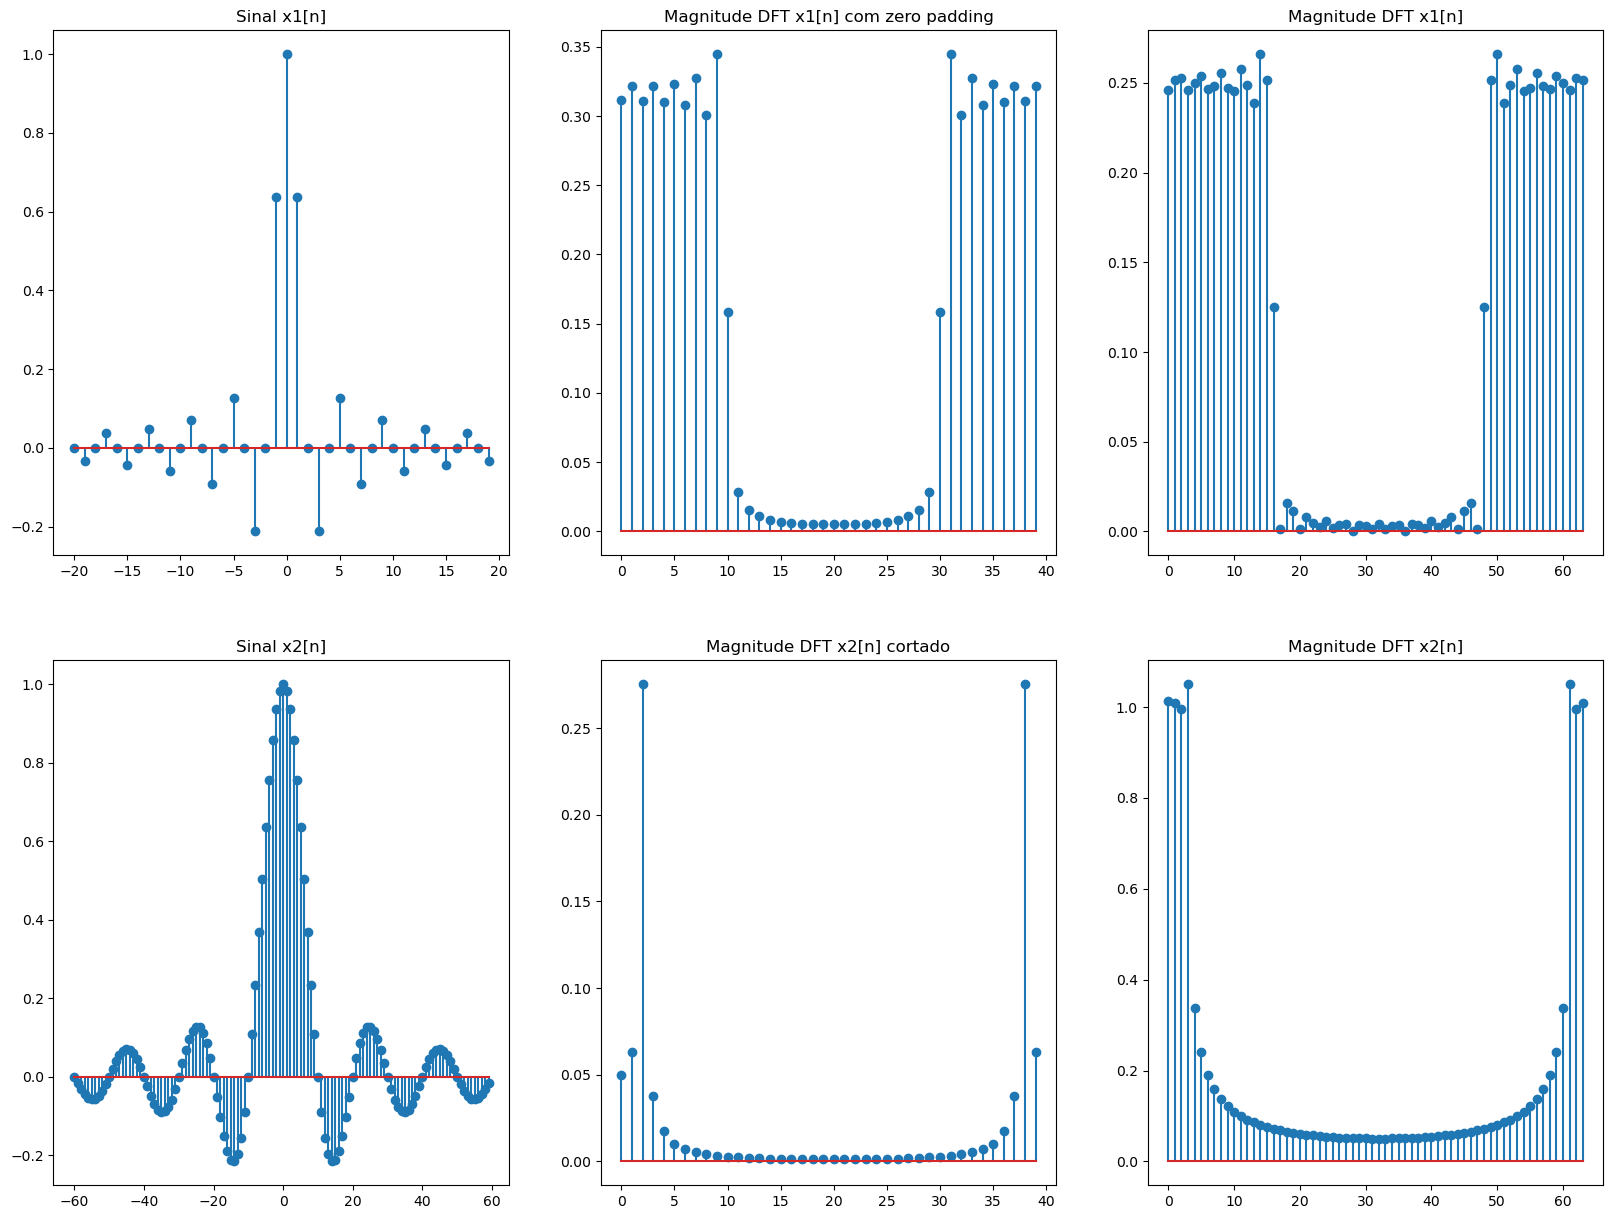

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal  

def DFT_func(signal,N):
    #Zero padding
    L=len(signal) #tamanho do sinal

    if L < N:
        signal = np.concatenate([signal,np.zeros(N-L)]) #concatena o sinal com N-L zeros
    else: #corta o sinal se for maior que N, em L>N ou L=N
        signal = signal[0:N] #corta o sinal se for maior que N
    #Transformada de Fourier Discreta

    X=np.zeros(N,dtype=complex) #inicializa o vetor da DFT com zeros
    for k in range(N):
        for n in range(N):
            X[k] += signal[n]*(np.exp((-2j*np.pi*k*n)/N)) #soma os valores da DFT

    return X/np.sqrt(N) #normaliza a DFT

L1 = 40   # Número total de amostras para o primeiro sinal
L2 = 120  # Número total de amostras para o segundo sinal
N = 64    # Tamanho da DFT a ser calculada

# Vetores de tempo centrados em zero para os sinais
# Isso cria sincs simétricos
n1 = np.arange(-L1/2, L1/2)
n2 = np.arange(-L2/2, L2/2)

# Sinal 1: Sinc mais comprimido no tempo (fator 0.5)
# Um fator > 0.2 fará ele decair mais rápido
x1 = np.sinc((0.5 * n1)*np.exp(1j*np.pi))  # Sinc deslocado em frequência por 0 rad/s

# Sinal 2: Sinc mais alargado no tempo (fator 0.1)
# Um fator < 0.2 fará ele decair mais lentamente
x2 = np.sinc(0.1 * n2)
N=64 #tamanho da DFT

X1_DFT= DFT_func(x1,N=L1) #DFT do sinal x1, L1=40 < N=64, com zero padding
X2_DFT= DFT_func(x2,N=L1) #DFT do sinal x2, L2=120 > N=64, cortado

X3_DFT= DFT_func(x1,N) #DFT do sinal x1 

X4_DFT= DFT_func(x2,N) #DFT do sinal x2 

fig , axs= plt.subplots(2,3, figsize=(20,15))

axs[0,0].stem(n1,x1)
axs[0,0].set_title('Sinal x1[n]')
axs[1,0].stem(n2,x2)
axs[1,0].set_title('Sinal x2[n]')
axs[0,1].stem(np.abs(X1_DFT))
axs[0,1].set_title('Magnitude DFT x1[n] com zero padding')
axs[1,1].stem(np.abs(X2_DFT))
axs[1,1].set_title('Magnitude DFT x2[n] cortado')
axs[0,2].stem(np.abs(X3_DFT))
axs[0,2].set_title('Magnitude DFT x1[n]')
axs[1,2].stem(np.abs(X4_DFT))
axs[1,2].set_title('Magnitude DFT x2[n]')

print('Sinal x1[n] com zero padding:', len(x1), 'amostras')
print('Sinal x2[n] cortado:', len(x2), 'amostras')